# AA-UTE 2026

## Demo 1 - Esquema básico de forecasting 

Adaptado del contenido del capítulo 5 del libro "Forecasting: Principles and Practice, the Pythonic Way" [1]

### Contenido

| Paso | Acción |
|------|--------|
| 1 | Cargar librerías necesarias |
| 2 | Cargar datos del libro |
| 3 | Explorar una serie temporal |
| 4 | Separar datos en train/test |
| 5 | Aplicar 4 métodos simples |
| 6 | Comparar resultados visualmente |
| 7 | Verificar residuos (¿quedó información sin usar?) |
| 8 | Construir intervalos de predicción |
| 9 | Medir precisión con métricas |

[1] Hyndman, R.J., Athanasopoulos, G., Garza, A., Challu, C., Mergenthaler, M., & Olivares, K.G. (2026). Forecasting: Principles and Practice, the Pythonic Way. OTexts: Melbourne, Australia. Available at: OTexts.com/fpppy. Accessed on 1 July 2026.

---

## PASO 1: Importar librerías

Vamos a usar estas herramientas:

- **`pandas` y `numpy`**: manejo de datos.
- **`matplotlib`**: gráficos.
- **`statsmodels`**: análisis estadístico de residuos.
- **`statsforecast`**: modelos de pronóstico simples.
- **`utilsforecast`**: evaluación de precisión.

In [1]:
from functools import partial
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para análisis de residuos
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Modelos de pronóstico
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, HistoricAverage, RandomWalkWithDrift

# Evaluación
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, smape, mase

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)


/home/agomez/anaconda3/envs/ts_ute/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## PASO 2: Cargar datos

El libro FPP en Python proporciona datos públicos. Vamos a cargar:

- **`aus_production_formatted.csv`**: producción trimestral en Australia (cerveza, ladrillos, etc.).
- **`gafa_stock.csv`**: precios de cierre diarios de empresas tech (GOOG, Apple, Facebook).



In [2]:
data_dir = Path('datos/fpppy')

files = ['global_economy.csv', 'aus_production_formatted.csv', 'gafa_stock.csv']

global_economy = pd.read_csv(data_dir / 'global_economy.csv', parse_dates=['ds'])
aus_production = pd.read_csv(data_dir / 'aus_production_formatted.csv', parse_dates=['ds'])
gafa_stock = pd.read_csv(data_dir / 'gafa_stock.csv', parse_dates=['ds'])

print('global_economy:', global_economy.shape)
print('aus_production:', aus_production.shape)
print('gafa_stock:', gafa_stock.shape)

global_economy: (15150, 9)
aus_production: (1308, 3)
gafa_stock: (30192, 3)


---

## PASO 3: Explorar una serie temporal

Vamos a trabajar con **Beer** (cerveza trimestral en Australia).

**¿Por qué Beer?**

- Tiene un patrón claro: **estacionalidad** anual + **tendencia**.
- Es útil para ver cómo los métodos capturan estos patrones.

In [3]:
# Filtrar solo Beer
beer = aus_production[aus_production['unique_id'] == 'Beer'].copy()

# Mostrar primeras filas
print('Primeras observaciones de Beer:')
display(beer.head(10))

print(f'\nObservaciones totales: {len(beer)}')
print(f'Rango temporal: {beer["ds"].min()} a {beer["ds"].max()}')

Primeras observaciones de Beer:


,unique_id,ds,y
0,Beer,1956-03-01,284.0
1,Beer,1956-06-01,213.0
2,Beer,1956-09-01,227.0
3,Beer,1956-12-01,308.0
4,Beer,1957-03-01,262.0
5,Beer,1957-06-01,228.0
6,Beer,1957-09-01,236.0
7,Beer,1957-12-01,320.0
8,Beer,1958-03-01,272.0
9,Beer,1958-06-01,233.0



Observaciones totales: 218
Rango temporal: 1956-03-01 00:00:00 a 2010-06-01 00:00:00


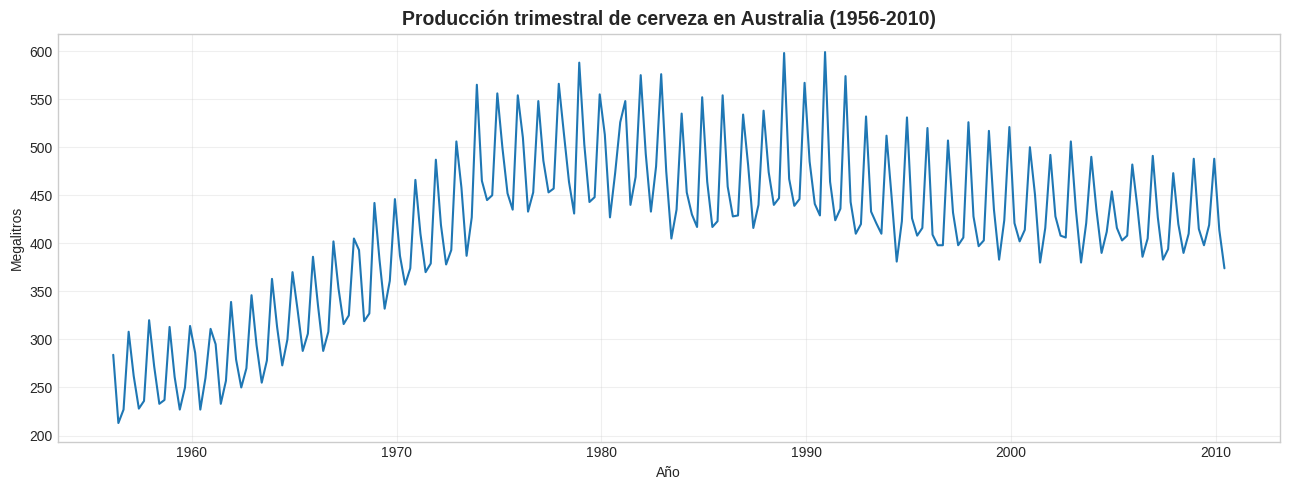


📊 Observaciones:
- Hay tendencia creciente (especialmente hasta 1980)
- Hay estacionalidad clara (picos y valles cada año)
- Hay variabilidad (ruido aleatorio)


In [4]:
# Visualizar la serie completa
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(beer['ds'], beer['y'], linewidth=1.5, color='tab:blue')
ax.set_title('Producción trimestral de cerveza en Australia (1956-2010)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Megalitros')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n📊 Observaciones:')
print('- Hay tendencia creciente (especialmente hasta 1980)')
print('- Hay estacionalidad clara (picos y valles cada año)')
print('- Hay variabilidad (ruido aleatorio)')

---

## PASO 4: Separar datos en train y test

**Regla fundamental:** los datos de test deben venir **al final** de la serie temporal (nunca al azar).

¿Por qué? Porque así simulamos lo que pasaría en el futuro real.

Vamos a usar:
- **Train**: datos desde 1992 hasta 2006 (inclusive).
- **Test**: datos desde 2007 en adelante (14 trimestres = 3.5 años).

In [5]:
# Filtrar desde 1992 (como en el capítulo original)
beer_desde_1992 = beer[beer['ds'] >= '1992'].copy()
print(f'Cerveza desde 1992: {len(beer_desde_1992)} observaciones')

# Separar train/test
train = beer_desde_1992[beer_desde_1992['ds'] < '2007'].copy()
test = beer_desde_1992[beer_desde_1992['ds'] >= '2007'].copy()

print(f'\n✅ Train: {len(train)} obs. ({train["ds"].min()} a {train["ds"].max()})')
print(f'✅ Test:  {len(test)} obs. ({test["ds"].min()} a {test["ds"].max()})')

Cerveza desde 1992: 74 observaciones

✅ Train: 60 obs. (1992-03-01 00:00:00 a 2006-12-01 00:00:00)
✅ Test:  14 obs. (2007-03-01 00:00:00 a 2010-06-01 00:00:00)


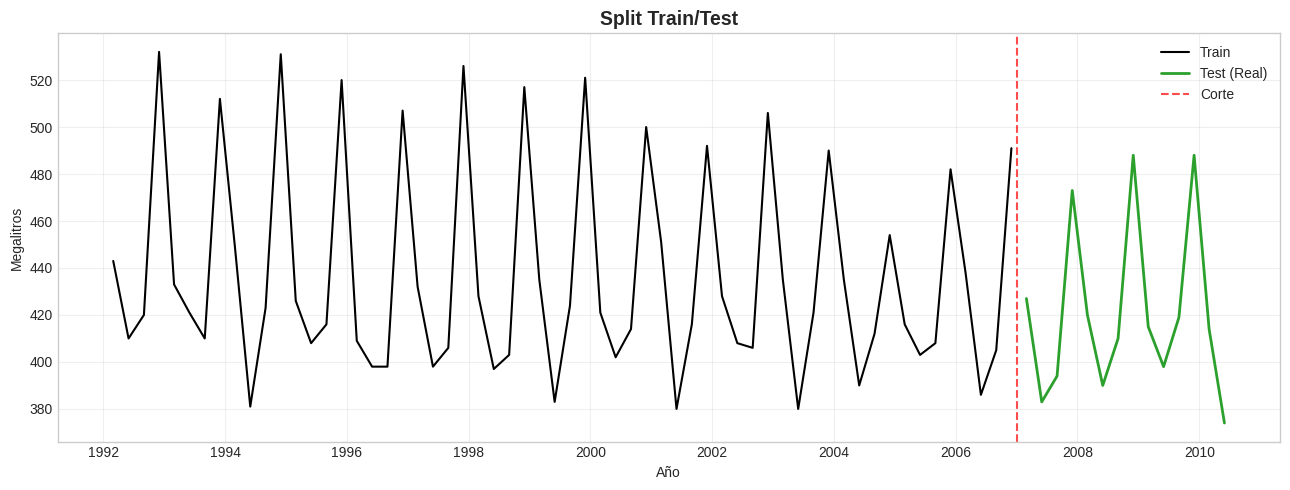

✅ División completada. Los valores reales de test (verde) serán nuestro benchmark.


In [6]:
# Visualizar la división
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train['ds'], train['y'], linewidth=1.5, color='black', label='Train')
ax.plot(test['ds'], test['y'], linewidth=2, color='tab:green', label='Test (Real)')
ax.axvline(pd.Timestamp('2007'), color='red', linestyle='--', alpha=0.7, label='Corte')
ax.set_title('Split Train/Test', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Megalitros')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('✅ División completada. Los valores reales de test (verde) serán nuestro benchmark.')

---

## PASO 5: Aplicar 4 métodos simples

El capítulo recomienda usar 4 **métodos benchmark** (baselines) que son:

1. **`HistoricAverage`**: todos los pronósticos = promedio histórico.
   - Fórmula: $\hat{y}_{T+h|T} = \bar{y}$

2. **`Naive`**: todos los pronósticos = último valor observado.
   - Fórmula: $\hat{y}_{T+h|T} = y_T$

3. **`SeasonalNaive(4)`**: cada trimestre futuro = mismo trimestre del año anterior.
   - Fórmula: $\hat{y}_{T+h|T} = y_{T+h-m}$ (donde $m=4$ trimestres)

4. **`RandomWalkWithDrift`**: like naive pero con tendencia.
   - Fórmula: $\hat{y}_{T+h|T} = y_T + h \cdot \text{drift}$

**¿Por qué usar estos?** Porque si tu modelo complejo no los supera, no vale la pena.

In [7]:
# Inicializar modelos
models = [
    HistoricAverage(),
    Naive(),
    SeasonalNaive(4),
    RandomWalkWithDrift()
]

# Crear objeto StatsForecast
sf = StatsForecast(
    models=models,
    freq='QS-DEC'  # Frecuencia trimestral (Quarter Start , First quarter in december)
)

# Entrenar y pronosticar
h = len(test)  # Horizonte = número de obs. en test
forecasts = sf.forecast(df=train, h=h)

# Agregar valores reales
forecasts = forecasts.assign(y=test['y'].to_numpy())

print('✅ Modelos entrenados y pronósticos generados.')
print(f'\nPronósticos para {h} períodos:')
display(forecasts.head(10))

✅ Modelos entrenados y pronósticos generados.

Pronósticos para 14 períodos:


,unique_id,ds,HistoricAverage,Naive,SeasonalNaive,RWD,y
0,Beer,2007-03-01,436.45,491.0,438.0,491.813559,427.0
1,Beer,2007-06-01,436.45,491.0,386.0,492.627119,383.0
2,Beer,2007-09-01,436.45,491.0,405.0,493.440678,394.0
3,Beer,2007-12-01,436.45,491.0,491.0,494.254237,473.0
4,Beer,2008-03-01,436.45,491.0,438.0,495.067797,420.0
5,Beer,2008-06-01,436.45,491.0,386.0,495.881356,390.0
6,Beer,2008-09-01,436.45,491.0,405.0,496.694915,410.0
7,Beer,2008-12-01,436.45,491.0,491.0,497.508475,488.0
8,Beer,2009-03-01,436.45,491.0,438.0,498.322034,415.0
9,Beer,2009-06-01,436.45,491.0,386.0,499.135593,398.0


---

## PASO 6: Comparar resultados visualmente

Ahora vamos a graficar todos los pronósticos juntos para ver cuál se acerca más a la realidad.

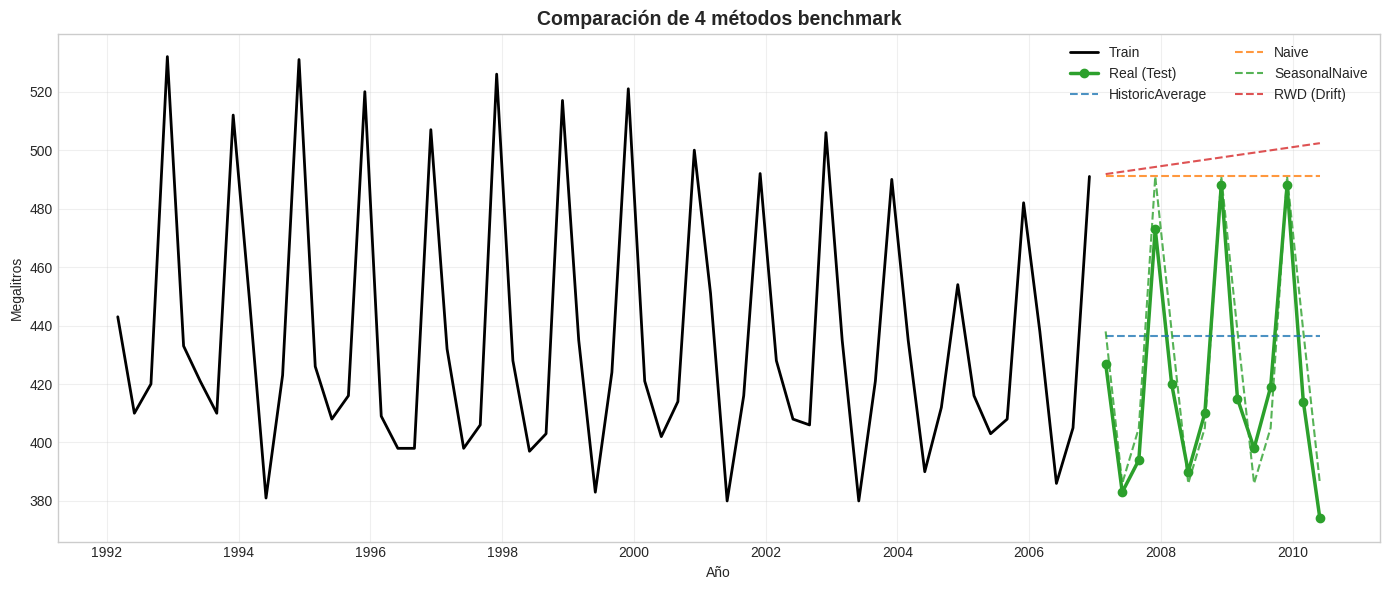


📊 Observación a simple vista:
- SeasonalNaive (línea punteada) sigue muy bien el patrón real
- Naive y HistoricAverage son más planos
- RWD intenta capturar la tendencia pero no la estacionalidad


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

# Datos históricos
ax.plot(train['ds'], train['y'], linewidth=2, color='black', label='Train')

# Valores reales del test
ax.plot(test['ds'], test['y'], linewidth=2.5, color='tab:green', label='Real (Test)', marker='o')

# Pronósticos
ax.plot(forecasts['ds'], forecasts['HistoricAverage'], '--', linewidth=1.5, label='HistoricAverage', alpha=0.8)
ax.plot(forecasts['ds'], forecasts['Naive'], '--', linewidth=1.5, label='Naive', alpha=0.8)
ax.plot(forecasts['ds'], forecasts['SeasonalNaive'], '--', linewidth=1.5, label='SeasonalNaive', alpha=0.8)
ax.plot(forecasts['ds'], forecasts['RWD'], '--', linewidth=1.5, label='RWD (Drift)', alpha=0.8)

ax.set_title('Comparación de 4 métodos benchmark', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Megalitros')
ax.legend(loc='best', ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n📊 Observación a simple vista:')
print('- SeasonalNaive (línea punteada) sigue muy bien el patrón real')
print('- Naive y HistoricAverage son más planos')
print('- RWD intenta capturar la tendencia pero no la estacionalidad')

El plot se puede hacer también con la función **plot_series** de utilsforecast

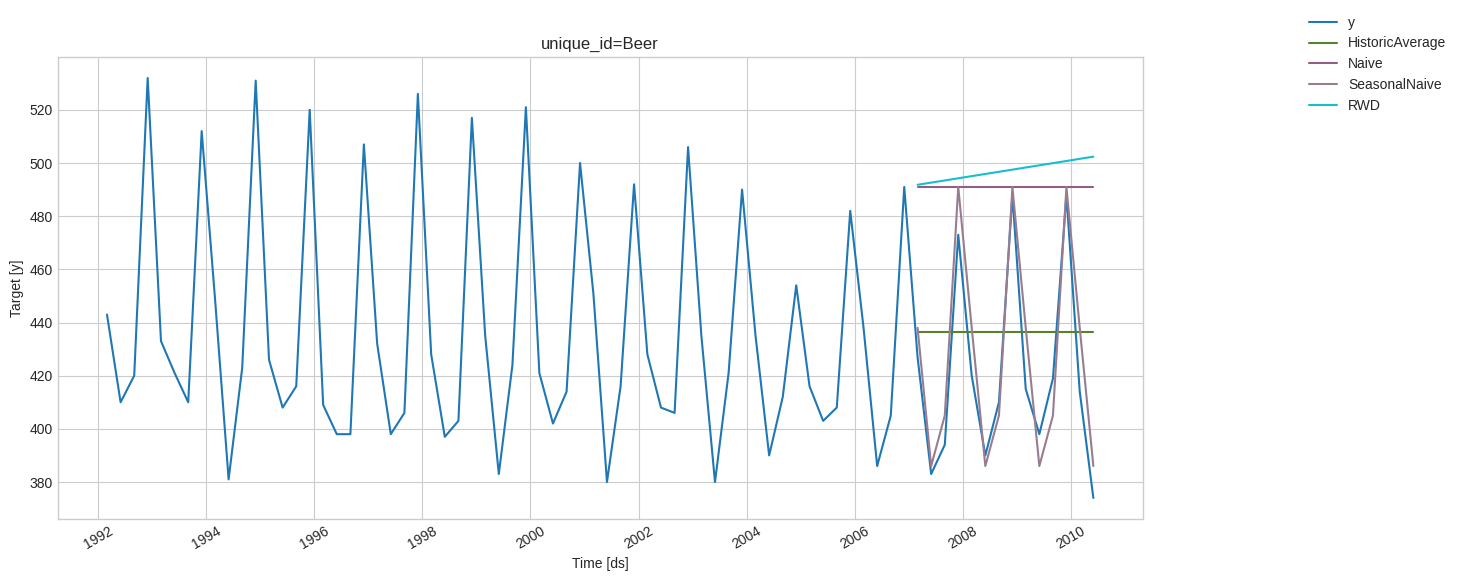

In [9]:
from utilsforecast.plotting import plot_series

fig, ax = plt.subplots(figsize=(14, 6))
plot_series(
    df=train,
    forecasts_df=forecasts,
    models=['HistoricAverage', 'Naive', 'SeasonalNaive', 'RWD'],
    ax=ax
)

---

## PASO 7: Inspeccionar residuos (¿quedó información sin usar?)

**Residuos** = lo que el modelo **no pudo predecir**.

$$e_t = y_t - \hat{y}_t$$

Si los residuos tienen **estructura** (autocorrelación, tendencia, ciclos), el modelo dejó información sin explicar.

Vamos a analizar el método Naive:

In [ ]:
# Obtener valores ajustados (fitted) del modelo Naive dentro de muestra
sf_fit = StatsForecast(models=[Naive()], freq='QS')
_ = sf_fit.forecast(df=train, h=len(test), fitted=True)
fitted_vals = sf_fit.forecast_fitted_values()

# Calcular residuos
fitted_vals['resid'] = fitted_vals['y'] - fitted_vals['Naive']

print('Primeros residuos (Naive en-muestra):')
display(fitted_vals[['ds', 'y', 'Naive', 'resid']].head(10))0111

Primeros residuos (Naive en-muestra):


,ds,y,Naive,resid
0,1992-03-01,443.0,NaN,NaN
1,1992-06-01,410.0,443.0,-33.0
2,1992-09-01,420.0,410.0,10.0
3,1992-12-01,532.0,420.0,112.0
4,1993-03-01,433.0,532.0,-99.0
5,1993-06-01,421.0,433.0,-12.0
6,1993-09-01,410.0,421.0,-11.0
7,1993-12-01,512.0,410.0,102.0
8,1994-03-01,449.0,512.0,-63.0
9,1994-06-01,381.0,449.0,-68.0


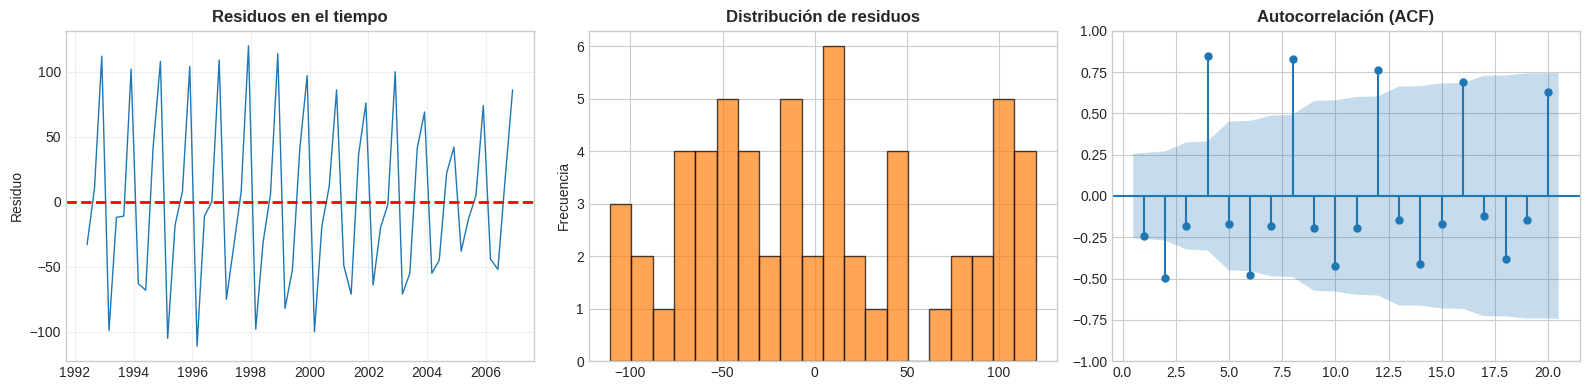

In [11]:
# Gráfico 1: Residuos en el tiempo
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuos serie temporal
axes[0].plot(fitted_vals['ds'], fitted_vals['resid'], linewidth=1, color='tab:blue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuos en el tiempo', fontweight='bold')
axes[0].set_ylabel('Residuo')
axes[0].grid(True, alpha=0.3)

# Histograma
resid_clean = fitted_vals['resid'].dropna()
axes[1].hist(resid_clean, bins=20, color='tab:orange', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de residuos', fontweight='bold')
axes[1].set_ylabel('Frecuencia')

# ACF (autocorrelación)
plot_acf(resid_clean, lags=20, zero=False, ax=axes[2])
axes[2].set_title('Autocorrelación (ACF)', fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
# Test de Ljung-Box: ¿hay autocorrelación significativa?
lb_test = acorr_ljungbox(resid_clean, lags=[4, 8, 12], return_df=True)
print('Test de Ljung-Box (H0: sin autocorrelación):')
display(lb_test)

print('\n📊 Interpretación:')
print('- Si p-value > 0.05: residuos parecen RUIDO BLANCO (✅ Buen modelo)')
print('- Si p-value < 0.05: residuos tienen AUTOCORRELACIÓN (⚠️ Modelo puede mejorar)')

Test de Ljung-Box (H0: sin autocorrelación):


,lb_stat,lb_pvalue
4,68.491136,4.725452e-14
8,136.696447,1.153378e-25
12,199.860224,3.485467e-36



📊 Interpretación:
- Si p-value > 0.05: residuos parecen RUIDO BLANCO (✅ Buen modelo)
- Si p-value < 0.05: residuos tienen AUTOCORRELACIÓN (⚠️ Modelo puede mejorar)


---

## PASO 8: Construir intervalos de predicción

Un pronóstico es poco inútil sin un **intervalo** que indique la incertidumbre.

Vamos a trabajar con **GOOG_Close** (precios diarios de Google) para mostrar intervalos.

In [13]:
# Preparar datos de GOOG
goog = gafa_stock[gafa_stock['unique_id'] == 'GOOG_Close'].copy()
goog_2015 = goog[(goog['ds'] >= '2015') & (goog['ds'] < '2016')].copy()
goog_2016_jan = goog[(goog['ds'] >= '2016') & (goog['ds'] < '2016-02')].copy()

# Re-indexar por días (el capítulo lo hace así)
goog_2015['ds'] = np.arange(len(goog_2015))
goog_2016_jan['ds'] = len(goog_2015) + np.arange(len(goog_2016_jan))

print(f'GOOG 2015: {len(goog_2015)} días')
print(f'GOOG enero 2016 (test): {len(goog_2016_jan)} días')

GOOG 2015: 252 días
GOOG enero 2016 (test): 19 días


In [14]:
# Generar pronósticos CON intervalos de confianza
sf_goog = StatsForecast(models=[Naive()], freq=1)

# level=[80, 95] significa: intervalos al 80% y 95%
goog_fc = sf_goog.forecast(df=goog_2015, h=len(goog_2016_jan), level=[80, 95])
goog_fc = goog_fc.assign(y=goog_2016_jan['y'].to_numpy())

print('Columnas generadas:')
print(goog_fc.columns.tolist())
print('\nPrimeros pronósticos:')
display(goog_fc.head())

Columnas generadas:
['unique_id', 'ds', 'Naive', 'Naive-lo-80', 'Naive-lo-95', 'Naive-hi-80', 'Naive-hi-95', 'y']

Primeros pronósticos:


,unique_id,ds,Naive,Naive-lo-80,Naive-lo-95,Naive-hi-80,Naive-hi-95,y
0,GOOG_Close,252,758.880005,744.539977,736.948825,773.220033,780.811185,741.840027
1,GOOG_Close,253,758.880005,738.600143,727.864632,779.159867,789.895378,742.580017
2,GOOG_Close,254,758.880005,734.042348,720.894087,783.717662,796.865923,743.619995
3,GOOG_Close,255,758.880005,730.199949,715.017645,787.560061,802.742365,726.390015
4,GOOG_Close,256,758.880005,726.814728,709.840395,790.945282,807.919615,714.469971


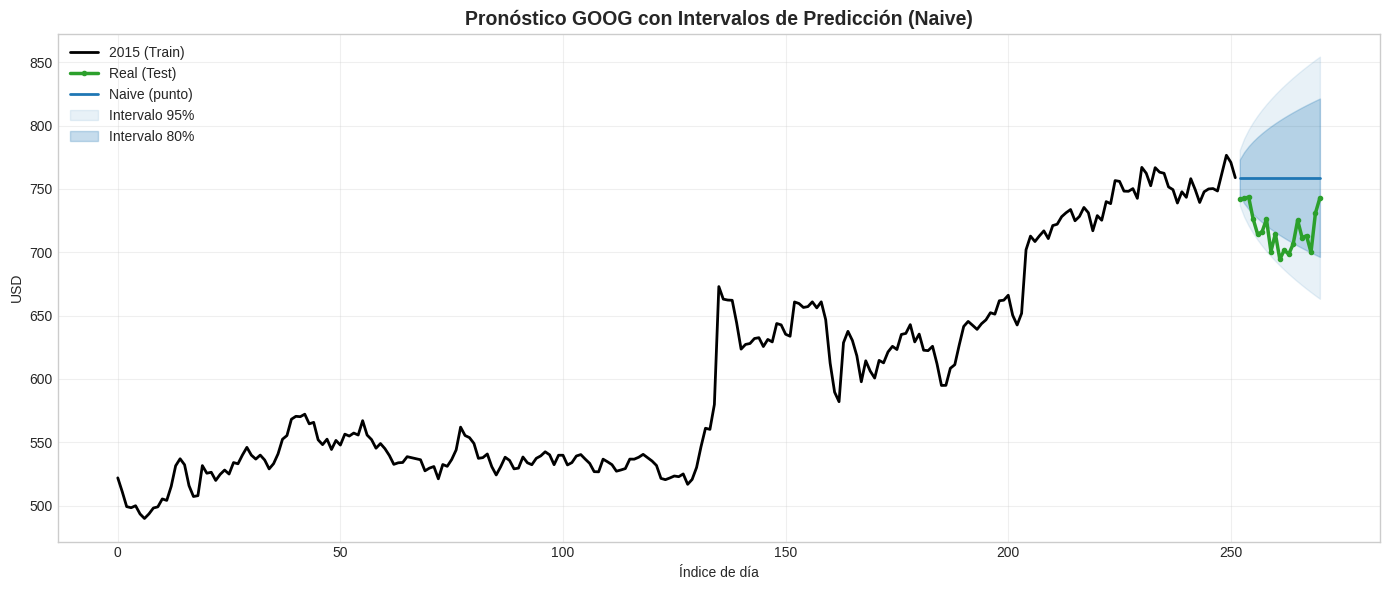

In [15]:
# Graficar con intervalos
fig, ax = plt.subplots(figsize=(14, 6))

# Datos train
ax.plot(goog_2015['ds'], goog_2015['y'], linewidth=2, color='black', label='2015 (Train)')

# Datos test (real)
ax.plot(goog_fc['ds'], goog_fc['y'], linewidth=2.5, color='tab:green', label='Real (Test)', marker='o', markersize=3)

# Pronóstico punto
ax.plot(goog_fc['ds'], goog_fc['Naive'], color='tab:blue', linewidth=2, label='Naive (punto)')

# Intervalos
ax.fill_between(
    goog_fc['ds'],
    goog_fc['Naive-lo-95'],
    goog_fc['Naive-hi-95'],
    color='tab:blue',
    alpha=0.1,
    label='Intervalo 95%'
)

ax.fill_between(
    goog_fc['ds'],
    goog_fc['Naive-lo-80'],
    goog_fc['Naive-hi-80'],
    color='tab:blue',
    alpha=0.25,
    label='Intervalo 80%'
)

ax.set_title('Pronóstico GOOG con Intervalos de Predicción (Naive)', fontsize=14, fontweight='bold')
ax.set_xlabel('Índice de día')
ax.set_ylabel('USD')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

## PASO 9: Evaluar con métricas

Ahora vamos a usar números para comparar los 4 métodos en el caso de la serie Beer.

Las métricas principales:

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **MAE** | $\frac{1}{n}\sum \|e_t\|$ | Error promedio absoluto |
| **RMSE** | $\sqrt{\frac{1}{n}\sum e_t^2}$ | Error cuadrático promedio (penaliza outliers) |
| **MAPE** | $\frac{100}{n}\sum \|\frac{e_t}{y_t}\|$ | Error porcentual (evita escala) |
| **sMAPE** | $\frac{100}{n}\sum \frac{2\|y_t-\hat{y}_t\|}{\|y_t\|+\|\hat{y}_t\|}$ | Error porcentual simétrico; reduce parte de la asimetría de MAPE |
| **MASE** | $\text{MASE}=\frac{\frac{1}{n}\sum_{j=1}^{n}\|e_j\|}{\frac{1}{T-m}\sum_{t=m+1}^{T}\|y_t-y_{t-m}\|}$ | Error absoluto escalado respecto al naive estacional |

**Regla:** valores menores = mejor pronóstico.

### ¿Qué significa sMAPE?

**sMAPE** significa *symmetric Mean Absolute Percentage Error* o **error porcentual absoluto medio simétrico**.

Se usa como alternativa a MAPE para evitar, al menos parcialmente, el problema de que MAPE penaliza de manera desigual errores positivos y negativos.

Aun así, conviene usarlo con criterio: cuando los valores observados y pronosticados están cerca de cero, también puede volverse inestable.

### ¿Qué significa MASE?

**MASE** significa *Mean Absolute Scaled Error* o **error absoluto medio escalado**.

La idea es dividir el error absoluto medio del modelo por el error absoluto medio de un método naive de referencia calculado sobre el conjunto de entrenamiento.

En una serie **estacional** como Beer, la referencia adecuada es el **naive estacional**, por eso en la fórmula aparece $y_t - y_{t-m}$ con $m=4$ trimestres.

Interpretación rápida:

- Si **MASE < 1**, el modelo es mejor que el naive estacional de referencia.
- Si **MASE = 1**, el modelo rinde parecido al benchmark naive estacional.
- Si **MASE > 1**, el modelo es peor que ese benchmark.

MASE permite comparar errores en una escala interpretable, incluso entre series distintas, sin depender de las unidades originales.

In [16]:
# Evaluar los 4 métodos
metrics_eval = evaluate(
    forecasts,
    train_df=train,
    metrics=[rmse, mae, mape, smape, partial(mase, seasonality=4)]
)

print('Evaluación de 4 métodos benchmark en Beer:')
display(metrics_eval)

Evaluación de 4 métodos benchmark en Beer:


,unique_id,metric,HistoricAverage,Naive,SeasonalNaive,RWD
0,Beer,rmse,38.889711,78.622516,13.488090,84.113750
1,Beer,mae,35.471429,70.071429,11.500000,76.173123
2,Beer,mape,0.085136,0.174390,0.027587,0.188969
3,Beer,smape,0.041485,0.078438,0.013620,0.084550
4,Beer,mase,2.437301,4.814724,0.790184,5.233981


In [17]:
# Pivot para mejor visualización
table = (
    metrics_eval
    .drop(columns=['unique_id'])
    .set_index('metric')
    .transpose()
    .reset_index()
    .rename(columns={'index': 'Modelo'})
    .sort_values('rmse')
)

print('\nComparación (ordenado por RMSE):')
display(table)

best = table.iloc[0]['Modelo']



Comparación (ordenado por RMSE):


metric,Modelo,rmse,mae,mape,smape,mase
2,SeasonalNaive,13.488090,11.500000,0.027587,0.013620,0.790184
0,HistoricAverage,38.889711,35.471429,0.085136,0.041485,2.437301
1,Naive,78.622516,70.071429,0.174390,0.078438,4.814724
3,RWD,84.113750,76.173123,0.188969,0.084550,5.233981


---

## Posibles extensiones

1. Probar con otra serie (por ejemplo, Bricks en aus_production).
2. Implementar transformaciones log para series con varianza no constante.
3. Probar descomposición STL (tendencia + estacional + irregular).
4. Explorar modelos más complejos (ARIMA, Exponential Smoothing).

---

## Posibles ejercicios

**Ejercicio 1**: Repetir el análisis completo con **Bricks** (ladrillos) de `aus_production`.
- ¿Cuál de los 4 métodos ganó?
- ¿Tienen los residuos autocorrelación significativa?

**Ejercicio 2**: En datos de GOOG, intentar con el método **RandomWalkWithDrift**.
- ¿Es mejor que Naive?
- ¿Por qué sí o por qué no?

**Ejercicio 3**: Descargar un dataset nuevo y aplicar el flujo completo.